# Held-out regression of θ from z

Plain linear regression sanity check: how much of θ is linearly recoverable from the learned summary z, on simulations the compression network never trained on. Compares the `v28` `cls_zreg_ablation` runs (`vmim` fac=2 vs `vmim_fac1` fac=1, plus the `sw`/`vicreg_inv` z-regularized variants) without fitting any flow.

In [40]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [41]:
import h5py, os

import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

from msi.utils import input_output

np.set_printoptions(precision=3)

# run registry

In [42]:
# base_dir = "/users/athomsen/scratch/deep_lss/runs/v16/rot_in_place/cls/lensing"
# params = ["Om", "s8", "w0", "Aia", "n_Aia", "bta"]

# base_dir = "/users/athomsen/scratch/deep_lss/runs/v16/rot_in_place/cls/clustering"
# params = ["Om", "s8", "w0", "bg1", "bg2", "bg3", "bg4"]

base_dir = "/users/athomsen/scratch/deep_lss/runs/v16/rot_in_place/cls/combined"
params = ["Om", "s8", "w0", "Aia", "n_Aia", "bta", "bg1", "bg2", "bg3", "bg4"]

runs = {
    "vmim (fac=2)": os.path.join(base_dir, "v29_vmim", "preds_1000000.h5"),
    "vmim_fac1 (fac=1)": os.path.join(base_dir, "v29_vmim_fac1", "preds_1000000.h5"),
    "vmim_sw": os.path.join(base_dir, "v29_vmim_sw", "preds_1000000.h5"),
    "vmim_vicreg_inv": os.path.join(base_dir, "v29_vmim_vicreg_inv", "preds_1000000.h5"),
}
# runs = {
#     "vmim (fac=2)": os.path.join(base_dir, "v28_vmim", "preds_1000000.h5"),
#     "vmim_fac1 (fac=1)": os.path.join(base_dir, "v28_vmim_fac1", "preds_1000000.h5"),
#     "vmim_sw": os.path.join(base_dir, "v28_vmim_sw", "preds_1000000.h5"),
#     "vmim_vicreg_inv": os.path.join(base_dir, "v28_vmim_vicreg_inv", "preds_1000000.h5"),
# }

# param_labels = [
#     r"$\Omega_m$", r"$\sigma_8$", r"$w_0$", r"$A_{IA}$", r"$\eta_{A_{IA}}$", r"$b_{ta}$",
#     r"$b_{g,1}$", r"$b_{g,2}$", r"$b_{g,3}$", r"$b_{g,4}$",
# ]

param_labels = params

# loader + regression

In [43]:
def regression_r2_per_param(z, theta, i_sobol, test_frac=0.2, seed=0):
    # split by unique i_sobol (cosmology) so different noise/signal realizations of the
    # same cosmology never leak across the regression train/eval split
    rng = np.random.default_rng(seed)
    unique_sobol = np.unique(i_sobol)
    rng.shuffle(unique_sobol)
    n_test = int(len(unique_sobol) * test_frac)
    test_mask = np.isin(i_sobol, unique_sobol[:n_test])
    train_mask = ~test_mask

    reg = LinearRegression().fit(z[train_mask], theta[train_mask])
    theta_pred = reg.predict(z[test_mask])

    return r2_score(theta[test_mask], theta_pred, multioutput="raw_values")


def load_and_regress(preds_file, test_frac=0.2, seed=0):
    z, theta, _, _ = input_output.load_network_preds_simple(preds_file)
    with h5py.File(preds_file, "r") as f:
        i_sobol = f["grid/i_sobol/test"][:]

    r2 = regression_r2_per_param(z, theta, i_sobol, test_frac=test_frac, seed=seed)
    print(f"{preds_file}\n  z.shape={z.shape}, theta.shape={theta.shape}\n  R^2={r2}")

    return r2

# run the comparison

In [44]:
r2_per_run = {label: load_and_regress(path) for label, path in runs.items()}

26-06-19 16:32:02 input_output INF   Loading predictions from /users/athomsen/scratch/deep_lss/runs/v16/rot_in_place/cls/combined/v29_vmim/preds_1000000.h5 


26-06-19 16:32:02 input_output INF   grid_preds.shape = (200000, 20) 
26-06-19 16:32:02 input_output INF   grid_cosmos.shape = (200000, 10) 
26-06-19 16:32:02 input_output INF   grid_(1,64,0) with shape (20,) 
26-06-19 16:32:02 input_output INF   grid_(2,64,0) with shape (20,) 
26-06-19 16:32:02 input_output INF   grid_(3,64,0) with shape (20,) 
26-06-19 16:32:02 input_output INF   grid_(4,64,0) with shape (20,) 
/users/athomsen/scratch/deep_lss/runs/v16/rot_in_place/cls/combined/v29_vmim/preds_1000000.h5
  z.shape=(200000, 20), theta.shape=(200000, 10)
  R^2=[0.888 0.943 0.452 0.966 0.769 0.128 0.919 0.908 0.92  0.918]
26-06-19 16:32:02 input_output INF   Loading predictions from /users/athomsen/scratch/deep_lss/runs/v16/rot_in_place/cls/combined/v29_vmim_fac1/preds_1000000.h5 
26-06-19 16:32:02 input_output INF   grid_preds.shape = (200000, 10) 
26-06-19 16:32:02 input_output INF   grid_cosmos.shape = (200000, 10) 
26-06-19 16:32:02 input_output INF   grid_(1,64,0) with shape (10,) 


# visualization

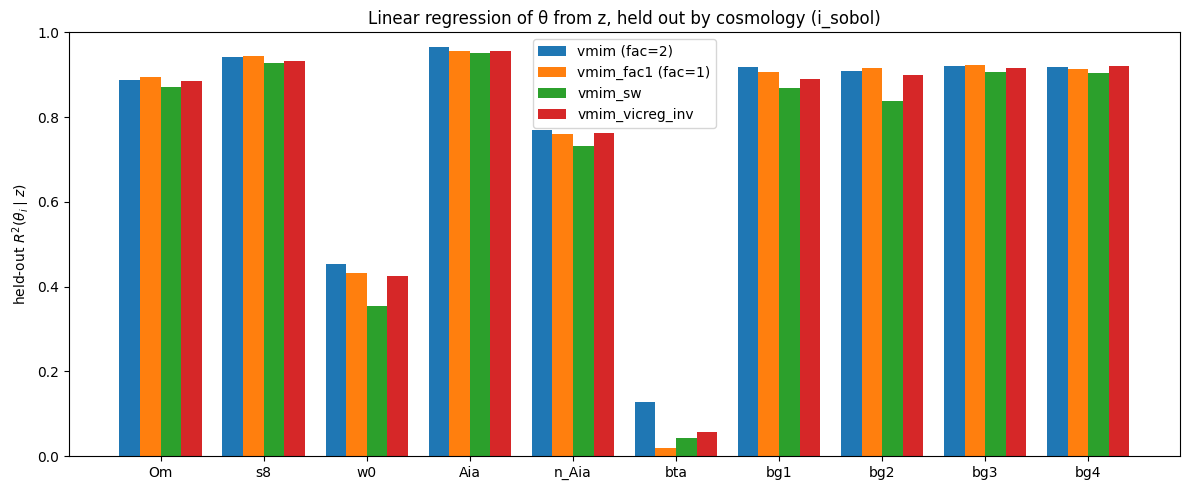

In [45]:
x = np.arange(len(params))
width = 0.8 / len(r2_per_run)

fig, ax = plt.subplots(figsize=(12, 5))
for i, (label, r2) in enumerate(r2_per_run.items()):
    ax.bar(x + i * width, r2, width=width, label=label)

ax.set_xticks(x + width * (len(r2_per_run) - 1) / 2)
ax.set_xticklabels(param_labels)
ax.set_ylabel(r"held-out $R^2(\theta_i \mid z)$")
ax.set_ylim(0, 1)
ax.legend()
ax.set_title("Linear regression of θ from z, held out by cosmology (i_sobol)")
plt.tight_layout()
plt.show()

In [46]:
header = f"{'param':<10}" + "".join(f"{label:>20}" for label in r2_per_run)
print(header)
for j, p in enumerate(params):
    row = f"{p:<10}" + "".join(f"{r2[j]:>20.3f}" for r2 in r2_per_run.values())
    print(row)

param             vmim (fac=2)   vmim_fac1 (fac=1)             vmim_sw     vmim_vicreg_inv
Om                       0.888               0.896               0.872               0.885
s8                       0.943               0.945               0.927               0.933
w0                       0.452               0.433               0.354               0.424
Aia                      0.966               0.955               0.951               0.957
n_Aia                    0.769               0.760               0.732               0.762
bta                      0.128               0.019               0.042               0.057
bg1                      0.919               0.906               0.868               0.889
bg2                      0.908               0.915               0.838               0.899
bg3                      0.920               0.923               0.906               0.916
bg4                      0.918               0.912               0.904               0.921